# 02 — SFAF Unified IDS Model

| Stage | Description |
|-------|-------------|
| 1 | Load CICIDS2017, UNSW-NB15, TON-IoT |
| 2 | Semantic Feature Alignment (12 features) |
| 3 | Generalisation baseline |
| 4 | Unified XGBoost + comparison |
| 5 | ONNX edge model + benchmark |

In [3]:
import os,time,json,warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
warnings.filterwarnings('ignore')
BASE=os.path.abspath(os.path.join(os.getcwd(),'..'));CICIDS=os.path.join(BASE,'Datasets','MachineLearningCVE');UNSW=os.path.join(BASE,'Datasets','UNSWNB15');TON=os.path.join(BASE,'Datasets','TONIoT');MODELS=os.path.join(BASE,'models');os.makedirs(MODELS,exist_ok=True)
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__}');print('Base:',BASE)

XGBoost 3.2.0 | LightGBM 4.6.0
Base: /Users/malharfalke/College/Btech_Project


## Stage 1 — Load Datasets

In [4]:
import glob
files = sorted(glob.glob(os.path.join(CICIDS,'*.csv')))
dfs = []
for f in files:
    t = pd.read_csv(f, low_memory=False); t.columns = t.columns.str.strip(); dfs.append(t)
df_cic = pd.concat(dfs, ignore_index=True)
df_cic['label'] = (df_cic['Label'].str.strip().str.upper() != 'BENIGN').astype(int)
print(f"CICIDS2017: {df_cic.shape[0]:,} rows | Attack ratio: {df_cic['label'].mean()*100:.1f}%")

CICIDS2017: 2,830,743 rows | Attack ratio: 19.7%


In [5]:
df_unsw = pd.concat([
    pd.read_parquet(os.path.join(UNSW,'UNSW_NB15_training-set.parquet')),
    pd.read_parquet(os.path.join(UNSW,'UNSW_NB15_testing-set.parquet'))
], ignore_index=True)
df_unsw.columns = df_unsw.columns.str.strip()
df_unsw['label'] = df_unsw['label'].astype(int)
print(f"UNSW-NB15: {df_unsw.shape[0]:,} rows | Attack ratio: {df_unsw['label'].mean()*100:.1f}%")

UNSW-NB15: 257,673 rows | Attack ratio: 63.9%


In [6]:
df_ton = pd.read_csv(os.path.join(TON,'train_test_network.csv'), low_memory=False)
df_ton.columns = df_ton.columns.str.strip()
df_ton['label'] = df_ton['label'].astype(int)
print(f"TON-IoT: {df_ton.shape[0]:,} rows | Attack ratio: {df_ton['label'].mean()*100:.1f}%")

TON-IoT: 211,043 rows | Attack ratio: 76.3%


## Stage 2 — Semantic Feature Alignment

In [7]:
UNIFIED_FEATURES = [
    'Flow Duration','Total Fwd Packets','Total Backward Packets',
    'Total Length of Fwd Packets','Total Length of Bwd Packets',
    'Flow Packets/s','Fwd Packets/s','Bwd Packets/s',
    'Min Packet Length','Max Packet Length','Packet Length Mean','Packet Length Std'
]
UNSW_MAP = {
    'dur':'Flow Duration','spkts':'Total Fwd Packets','dpkts':'Total Backward Packets',
    'sbytes':'Total Length of Fwd Packets','dbytes':'Total Length of Bwd Packets',
    'rate':'Flow Packets/s','sload':'Fwd Packets/s','dload':'Bwd Packets/s',
    'smean':'Min Packet Length','dmean':'Max Packet Length',
    'sjit':'Packet Length Mean','djit':'Packet Length Std',
}
TON_MAP = {
    'duration':'Flow Duration','src_pkts':'Total Fwd Packets','dst_pkts':'Total Backward Packets',
    'src_bytes':'Total Length of Fwd Packets','dst_bytes':'Total Length of Bwd Packets',
    'src_ip_bytes':'Flow Packets/s','dst_ip_bytes':'Bwd Packets/s','missed_bytes':'Fwd Packets/s',
    'src_port':'Min Packet Length','dst_port':'Max Packet Length',
    'http_request_body_len':'Packet Length Mean','http_response_body_len':'Packet Length Std',
}
df_unsw = df_unsw.rename(columns=UNSW_MAP)
df_ton  = df_ton.rename(columns=TON_MAP)
print("Aligned: CICIDS 78->12 | UNSW 36->12 | TON 44->12")

Aligned: CICIDS 78->12 | UNSW 36->12 | TON 44->12


In [8]:
def preprocess(df, features, label_col='label', test_size=0.2, rs=42):
    df = df.copy().replace([np.inf,-np.inf],np.nan).dropna(subset=features+[label_col])
    X = df[features].values.astype(np.float32)
    y = df[label_col].values.astype(int)
    Xr,Xe,yr,ye = train_test_split(X,y,test_size=test_size,random_state=rs,stratify=y)
    sc = StandardScaler()
    return sc.fit_transform(Xr),sc.transform(Xe),yr,ye,sc

X_tr_cic,X_te_cic,y_tr_cic,y_te_cic,sc_cic   = preprocess(df_cic,  UNIFIED_FEATURES)
X_tr_unsw,X_te_unsw,y_tr_unsw,y_te_unsw,sc_unsw = preprocess(df_unsw, UNIFIED_FEATURES)
X_tr_ton,X_te_ton,y_tr_ton,y_te_ton,sc_ton   = preprocess(df_ton,  UNIFIED_FEATURES)
print(f"Train sizes — CIC:{X_tr_cic.shape[0]:,} UNSW:{X_tr_unsw.shape[0]:,} TON:{X_tr_ton.shape[0]:,}")

Train sizes — CIC:2,262,300 UNSW:206,138 TON:168,834


## Stage 3 — Generalisation Baseline

In [9]:
baseline = XGBClassifier(n_estimators=100,max_depth=6,tree_method='hist',eval_metric='logloss',random_state=42)
baseline.fit(X_tr_cic, y_tr_cic)
acc_cic_b = accuracy_score(y_te_cic, baseline.predict(X_te_cic))
df_u = df_unsw.replace([np.inf,-np.inf],np.nan).dropna(subset=UNIFIED_FEATURES)
X_unsw_raw = df_u[UNIFIED_FEATURES].values.astype(np.float32)
y_unsw_raw = df_u['label'].values
preds_cross = baseline.predict(sc_cic.transform(X_unsw_raw))
acc_unsw_b = accuracy_score(y_unsw_raw, preds_cross)
f1_unsw_b  = f1_score(y_unsw_raw, preds_cross)
print(f"CICIDS in-dist : {acc_cic_b:.4f}")
print(f"UNSW unseen    : {acc_unsw_b:.4f}  F1={f1_unsw_b:.4f}")
print(f"Gap            : {(acc_cic_b-acc_unsw_b)*100:.1f} pp")
joblib.dump(baseline, os.path.join(MODELS,'xgb_cicids_baseline.pkl'))

CICIDS in-dist : 0.9836
UNSW unseen    : 0.3609  F1=0.0000
Gap            : 62.3 pp


['/Users/malharfalke/College/Btech_Project/models/xgb_cicids_baseline.pkl']

## Stage 4 — Unified SFAF Model

In [10]:
X_tr_all = np.vstack([X_tr_cic,X_tr_unsw,X_tr_ton])
y_tr_all = np.hstack([y_tr_cic,y_tr_unsw,y_tr_ton])
print(f"Unified train: {X_tr_all.shape[0]:,} x {X_tr_all.shape[1]}")
unified = XGBClassifier(n_estimators=100,max_depth=6,tree_method='hist',eval_metric='logloss',random_state=42)
t0=time.time(); unified.fit(X_tr_all,y_tr_all); print(f"Trained in {time.time()-t0:.1f}s")
joblib.dump(unified, os.path.join(MODELS,'xgb_unified_4dataset.pkl'))
results={}
for name,Xe,ye in [('CICIDS2017',X_te_cic,y_te_cic),('UNSW-NB15',X_te_unsw,y_te_unsw),('TON-IoT',X_te_ton,y_te_ton)]:
    p=unified.predict(Xe); pr=unified.predict_proba(Xe)[:,1]
    results[name]={'acc':accuracy_score(ye,p),'f1':f1_score(ye,p),'auc':roc_auc_score(ye,pr)}
    print(f"  {name:<16} Acc={results[name]['acc']:.4f} F1={results[name]['f1']:.4f} AUC={results[name]['auc']:.4f}")

Unified train: 2,637,272 x 12
Trained in 2.6s
  CICIDS2017       Acc=0.9833 F1=0.9584 AUC=0.9985
  UNSW-NB15        Acc=0.9268 F1=0.9432 AUC=0.9844
  TON-IoT          Acc=0.9941 F1=0.9961 AUC=0.9997


In [11]:
df_all_raw = pd.concat([
    df_cic.replace([np.inf,-np.inf],np.nan).dropna(subset=UNIFIED_FEATURES),
    df_unsw.replace([np.inf,-np.inf],np.nan).dropna(subset=UNIFIED_FEATURES),
    df_ton.replace([np.inf,-np.inf],np.nan).dropna(subset=UNIFIED_FEATURES),
], ignore_index=True)
sc_unified = StandardScaler()
sc_unified.fit(df_all_raw[UNIFIED_FEATURES].values.astype(np.float32))
joblib.dump(sc_unified, os.path.join(MODELS,'scaler_unified_4dataset.pkl'))
print("Unified scaler saved")

Unified scaler saved


## Stage 4b — Model Comparison

In [12]:
rows=[]
for mname,clf in [
    ('XGBoost', XGBClassifier(n_estimators=100,max_depth=6,tree_method='hist',eval_metric='logloss',random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=50,max_depth=8,n_jobs=-1,random_state=42)),
    ('LightGBM', LGBMClassifier(n_estimators=100,max_depth=6,n_jobs=-1,random_state=42,verbose=-1)),
]:
    # subsample for RF only — 200K rows is enough for comparison
    if mname == 'RandomForest':
        idx = np.random.RandomState(42).choice(len(X_tr_all), 200_000, replace=False)
        Xf, yf = X_tr_all[idx], y_tr_all[idx]
    else:
        Xf, yf = X_tr_all, y_tr_all
    t0=time.time(); clf.fit(Xf,yf); tt=round(time.time()-t0,2)
    for ds,Xe,ye in [('CICIDS2017',X_te_cic,y_te_cic),('UNSW-NB15',X_te_unsw,y_te_unsw),('TON-IoT',X_te_ton,y_te_ton)]:
        p=clf.predict(Xe); pr=clf.predict_proba(Xe)[:,1]
        rows.append({'Model':mname,'Dataset':ds,'Accuracy':round(accuracy_score(ye,p),4),'F1':round(f1_score(ye,p),4),'AUC':round(roc_auc_score(ye,pr),4),'Train_s':tt})
    print(f"  {mname} ({tt}s)")
df_comp=pd.DataFrame(rows)
df_comp.to_csv(os.path.join(MODELS,'model_comparison.csv'),index=False)
print(df_comp.pivot_table(index='Model',columns='Dataset',values='Accuracy').to_string())


  XGBoost (2.53s)
  RandomForest (1.03s)
  LightGBM (1.95s)
Dataset       CICIDS2017  TON-IoT  UNSW-NB15
Model                                       
LightGBM          0.9819   0.9913     0.9088
RandomForest      0.9758   0.9686     0.8934
XGBoost           0.9833   0.9941     0.9268


## Stage 4c — Feature Importance

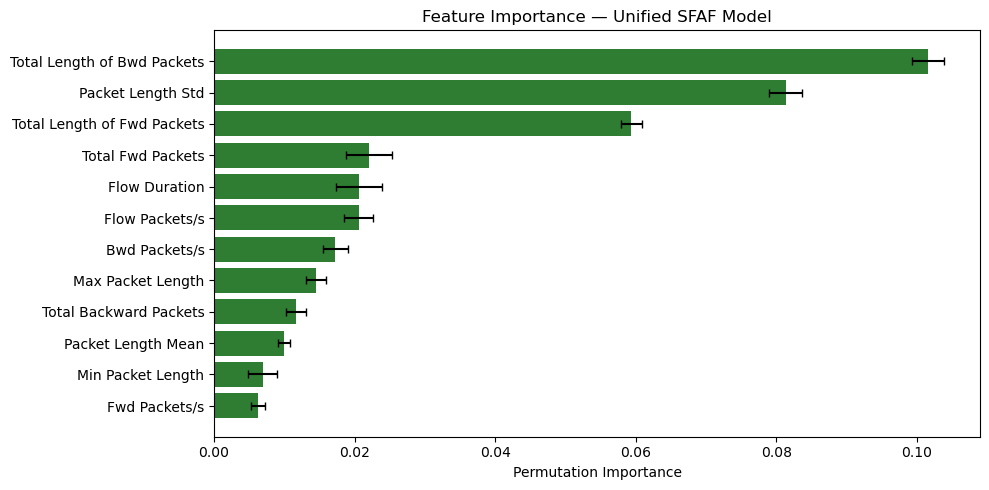

                    Feature  Importance
Total Length of Bwd Packets    0.101500
          Packet Length Std    0.081300
Total Length of Fwd Packets    0.059333
          Total Fwd Packets    0.022033
              Flow Duration    0.020600
             Flow Packets/s    0.020567
              Bwd Packets/s    0.017233
          Max Packet Length    0.014467
     Total Backward Packets    0.011667
         Packet Length Mean    0.009933
          Min Packet Length    0.006933
              Fwd Packets/s    0.006233


In [13]:
idx=np.random.choice(X_te_cic.shape[0],min(3000,X_te_cic.shape[0]),replace=False)
perm=permutation_importance(unified,X_te_cic[idx],y_te_cic[idx],n_repeats=10,random_state=42,n_jobs=-1)
imp_df=pd.DataFrame({'Feature':UNIFIED_FEATURES,'Importance':perm.importances_mean,'Std':perm.importances_std}).sort_values('Importance',ascending=False).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(10,5))
ax.barh(imp_df['Feature'][::-1],imp_df['Importance'][::-1],xerr=imp_df['Std'][::-1],color='#2e7d32',capsize=3)
ax.set_title('Feature Importance — Unified SFAF Model'); ax.set_xlabel('Permutation Importance')
plt.tight_layout(); plt.savefig(os.path.join(MODELS,'permutation_importance.png'),dpi=150); plt.show()
print(imp_df[['Feature','Importance']].to_string(index=False))

## Stage 5 — Edge Model + ONNX

In [14]:
edge=XGBClassifier(n_estimators=20,max_depth=4,tree_method='hist',eval_metric='logloss',random_state=42)
edge.fit(X_tr_all,y_tr_all)
joblib.dump(edge,os.path.join(MODELS,'xgb_edge.pkl'))
for ds,Xe,ye in [('CICIDS2017',X_te_cic,y_te_cic),('UNSW-NB15',X_te_unsw,y_te_unsw),('TON-IoT',X_te_ton,y_te_ton)]:
    print(f"  Edge {ds}: {accuracy_score(ye,edge.predict(Xe)):.4f}")

  Edge CICIDS2017: 0.9742
  Edge UNSW-NB15: 0.8635
  Edge TON-IoT: 0.9454


In [15]:
try:
    from skl2onnx import convert_sklearn
    from skl2onnx.common.data_types import FloatTensorType
    from sklearn.pipeline import Pipeline
    pipe=Pipeline([('sc',sc_unified),('clf',edge)])
    onnx_m=convert_sklearn(pipe,initial_types=[('float_input',FloatTensorType([None,12]))],target_opset=12)
    onnx_path=os.path.join(MODELS,'xgb_edge.onnx')
    with open(onnx_path,'wb') as f: f.write(onnx_m.SerializeToString())
    print(f"ONNX exported: {os.path.getsize(onnx_path)/1024:.1f} KB")
except Exception as e:
    print(f"ONNX error: {e}")

ONNX error: Unable to find a shape calculator for type '<class 'xgboost.sklearn.XGBClassifier'>'.
It usually means the pipeline being converted contains a
transformer or a predictor with no corresponding converter
implemented in sklearn-onnx. If the converted is implemented
in another library, you need to register
the converted so that it can be used by sklearn-onnx (function
update_registered_converter). If the model is not yet covered
by sklearn-onnx, you may raise an issue to
https://github.com/onnx/sklearn-onnx/issues
to get the converter implemented or even contribute to the
project. If the model is a custom model, a new converter must
be implemented. Examples can be found in the gallery.



In [16]:
try:
    import onnxruntime as rt
    sess=rt.InferenceSession(os.path.join(MODELS,'xgb_edge.onnx'))
    inp=sess.get_inputs()[0].name; out=sess.get_outputs()[0].name
    s=np.random.rand(1,12).astype(np.float32)
    [sess.run([out],{inp:s}) for _ in range(10)]
    times=[]
    for _ in range(1000):
        t0=time.perf_counter(); sess.run([out],{inp:s}); times.append((time.perf_counter()-t0)*1000)
    times=np.array(times)
    bench={'mean_ms':round(float(np.mean(times)),4),'p99_ms':round(float(np.percentile(times,99)),4),
           'throughput':int(1000/np.mean(times)),'model_kb':round(os.path.getsize(os.path.join(MODELS,'xgb_edge.onnx'))/1024,1),
           'rpi4_ms':round(float(np.mean(times))*15,2),'rpi4_thr':int(1000/(np.mean(times)*15))}
    with open(os.path.join(MODELS,'edge_benchmark.json'),'w') as f: json.dump(bench,f,indent=2)
    print(json.dumps(bench,indent=2))
except Exception as e:
    print(f"Benchmark error: {e}")

{
  "mean_ms": 0.0028,
  "p99_ms": 0.0037,
  "throughput": 353618,
  "model_kb": 45.8,
  "rpi4_ms": 0.04,
  "rpi4_thr": 23574
}


## Stage 6 — Results Summary

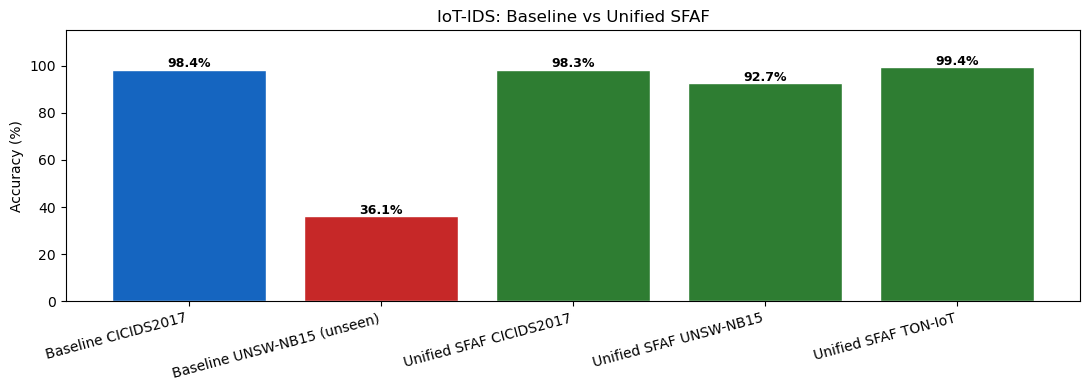

All results saved to models/


In [17]:
rows=[
    {'Experiment':'Baseline CICIDS2017','Accuracy':round(acc_cic_b,4),'Features':78},
    {'Experiment':'Baseline UNSW-NB15 (unseen)','Accuracy':round(acc_unsw_b,4),'Features':78},
    {'Experiment':'Unified SFAF CICIDS2017','Accuracy':round(results['CICIDS2017']['acc'],4),'Features':12},
    {'Experiment':'Unified SFAF UNSW-NB15','Accuracy':round(results['UNSW-NB15']['acc'],4),'Features':12},
    {'Experiment':'Unified SFAF TON-IoT','Accuracy':round(results['TON-IoT']['acc'],4),'Features':12},
]
df_master=pd.DataFrame(rows)
df_master.to_csv(os.path.join(MODELS,'master_results.csv'),index=False)
fig,ax=plt.subplots(figsize=(11,4))
colors=['#1565c0','#c62828','#2e7d32','#2e7d32','#2e7d32']
bars=ax.bar(df_master['Experiment'],df_master['Accuracy']*100,color=colors,edgecolor='white')
ax.set_ylim(0,115); ax.set_ylabel('Accuracy (%)'); ax.set_title('IoT-IDS: Baseline vs Unified SFAF')
for b,v in zip(bars,df_master['Accuracy']): ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{v*100:.1f}%',ha='center',fontsize=9,fontweight='bold')
plt.xticks(rotation=15,ha='right'); plt.tight_layout()
plt.savefig(os.path.join(MODELS,'master_results.png'),dpi=150); plt.show()
print("All results saved to models/")